Using CIFAR-10 dataset

cifar-10 dataset contains 60000 images of 10 classes.Each class cotaining 6000 images. 50000 images for training and 10000 images for testing. The classes are compltely mutually exclusive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras import datasets,layers,models #using tensorflow we are calling an api called keras which has many datasets in it

C:\Users\ketha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#from libraries we are importing modules
#datasets module-provides access to many preloaded datasets commonly used in ml and dl tasks
#layers module-contains many nn layers like dense,conv2d,maxpooling2d,dropout
#models modules-provides tools to define and manages models like Sequential

In [3]:
(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

C:\Users\ketha\anaconda3\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
type(train_images)

numpy.ndarray

In [5]:
type(test_images)

numpy.ndarray

In [6]:
train_images.shape #50k images,each having 32-height,32-width,3-channels. If its a grey scale we can drop 3

(50000, 32, 32, 3)

In [7]:
test_images.shape

(10000, 32, 32, 3)

In [8]:
train_labels.shape

(50000, 1)

In [9]:
train_images[0].shape # each having;32-height,32-layers,each layer having 3-channels

(32, 32, 3)

In [10]:
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [11]:
train_images[0][0] #layer 1 of first training sample image

array([[ 59,  62,  63],
       [ 43,  46,  45],
       [ 50,  48,  43],
       [ 68,  54,  42],
       [ 98,  73,  52],
       [119,  91,  63],
       [139, 107,  75],
       [145, 110,  80],
       [149, 117,  89],
       [149, 120,  93],
       [131, 103,  77],
       [125,  99,  76],
       [142, 115,  91],
       [144, 112,  86],
       [137, 105,  79],
       [129,  97,  71],
       [137, 106,  79],
       [134, 106,  76],
       [124,  97,  64],
       [139, 113,  78],
       [139, 112,  75],
       [133, 105,  69],
       [136, 105,  74],
       [139, 108,  77],
       [152, 120,  89],
       [163, 131, 100],
       [168, 136, 108],
       [159, 129, 102],
       [158, 130, 104],
       [158, 132, 108],
       [152, 125, 102],
       [148, 124, 103]], dtype=uint8)

In [12]:
image=train_images[12]

Extracting RGB channels respectively:

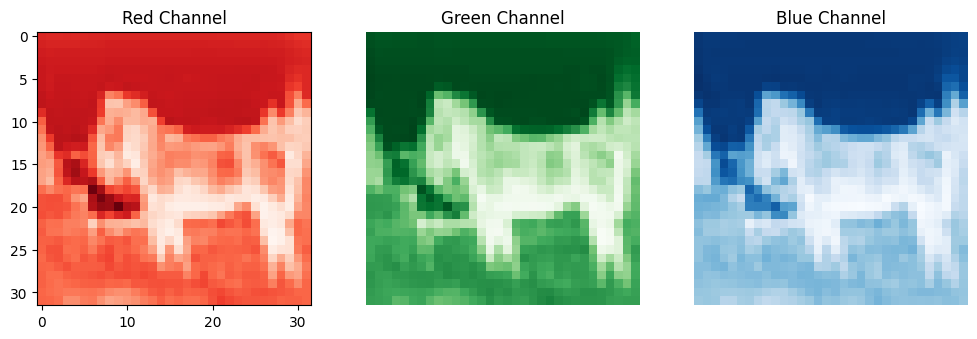

In [13]:
red=image[:,:,0] #extracting red channel
green=image[:,:,1]
blue=image[:,:,2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(red,cmap='Reds')
plt.title("Red Channel")

plt.subplot(1, 3, 2)
plt.imshow(green, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blue, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.show()

In [14]:
red

array([[164, 162, 162, ..., 157, 153, 153],
       [168, 166, 166, ..., 164, 160, 158],
       [172, 170, 171, ..., 168, 165, 163],
       ...,
       [123, 117, 112, ..., 117,  95, 120],
       [120, 116, 112, ..., 126, 120, 120],
       [121, 120, 116, ..., 124, 124, 120]], shape=(32, 32), dtype=uint8)

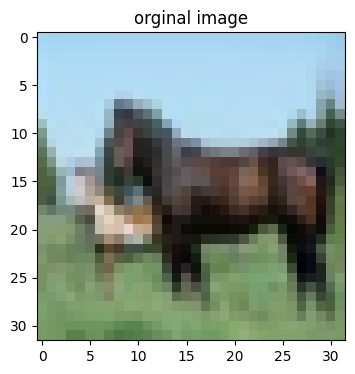

In [15]:
plt.figure(figsize=(12, 4))
plt.imshow(train_images[12])
plt.title("orginal image")
plt.show()

In [16]:
np.unique(train_labels) #10 unique classes ,label encoded to 0-9

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

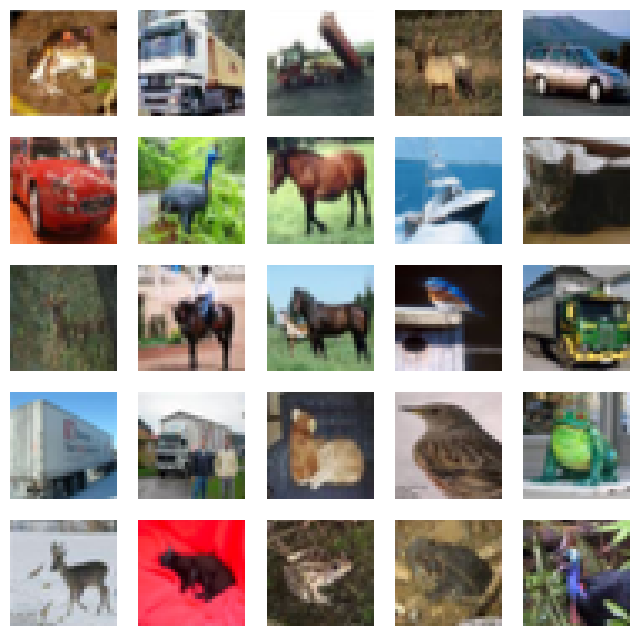

In [17]:
classnames=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
    plt.xlabel(classnames[train_labels[i][0]]) #[i][0] becoz each label is again stored in a array
plt.show()

In [18]:
train_labels 

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [19]:
pip install opencv-python #library in python that is used to import images from our computer files

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#library': Expected package name at the start of dependency specifier
    #library
    ^


In [20]:
import cv2


In [21]:
image=cv2.imread("C:\\Users\\ketha\\OneDrive\\Desktop\\lenna.jpg") #cv2.imread is a function from the OpenCV library (Python) used to read/load an image from a file into memory.

OpenCV reads images in BGR order, not RGB (opposite of most libraries)

In [22]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # convert BGR to RGB for display

In [23]:
### Define the filters (kernels)
#dictionary oof filters
filters = {
    'Original': np.array([[1,0,0], [0,1,0], [0,0,1]]),  # original image - leaves the image unchanged

    'Edge Detection': np.array([[-1,-1,-1],
                                [-1, 8,-1],
                                [-1,-1,-1]]),  # highlights regions with sharp changes in pixel density

    'Sharpen': np.array([[ 0,-1, 0],
                         [-1, 5,-1],
                         [ 0,-1, 0]]),  # enhances edges and details

    'Blur': np.array([[1/16, 2/16, 1/16],
                      [2/16, 4/16, 2/16],
                      [1/16, 2/16, 1/16]]),  # smoothing filter

    'Emboss': np.array([[-2,-1,0],
                        [-1, 1,1], #creates 3d like filter
                        [ 0, 1,2]])
}

In [24]:
filtered_images={}
filtered_images['Orginal']=image
for name,kernel in filters.items():
    if name=='Orginal':
        continue
    #filter application step
    filtered=cv2.filter2D(image,-1,kernel) #image-i/p,-1=same depth as i/p image(pixel val range=0-255),kernel=filter to be applied
    filtered_images[name]=filtered #stores the filtered images into this dictionary called filtered images

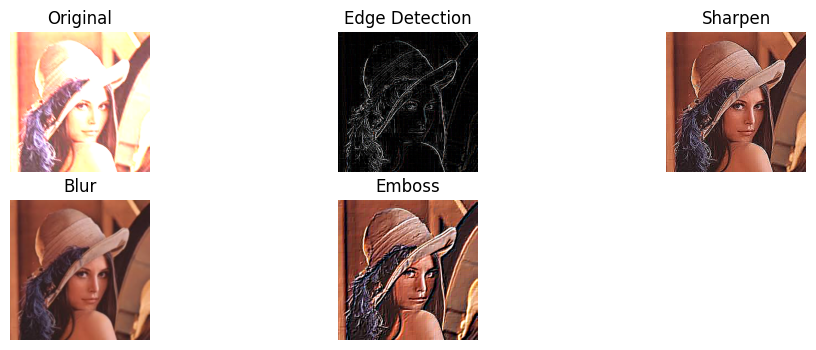

In [25]:
plt.figure(figsize=(12,4))
i=1
for name,kernel in filters.items():
    plt.subplot(2,3,i)
    plt.imshow(filtered_images[name])
    plt.title(name)
    plt.axis('off')
    i=i+1
plt.show()

creating convolutional base for the model

conv1d-text,conv2d-images(params-filters,kernel size..etc)

In [26]:
model=models.Sequential() #so that,all the layers of the model are in sequence
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #first 2d convolution layer with 32 filters
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #another 2d convolution layer with 664 filters
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #another 2d convolution layer with 664 filters
#can either end with conv layer or maxpooling layer

C:\Users\ketha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
#pip install pydot

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

cov2d 1st layer-output shape=(30*30) for each of 32 filters

height and width of feature map can be calculate thru formulas to crosscheck

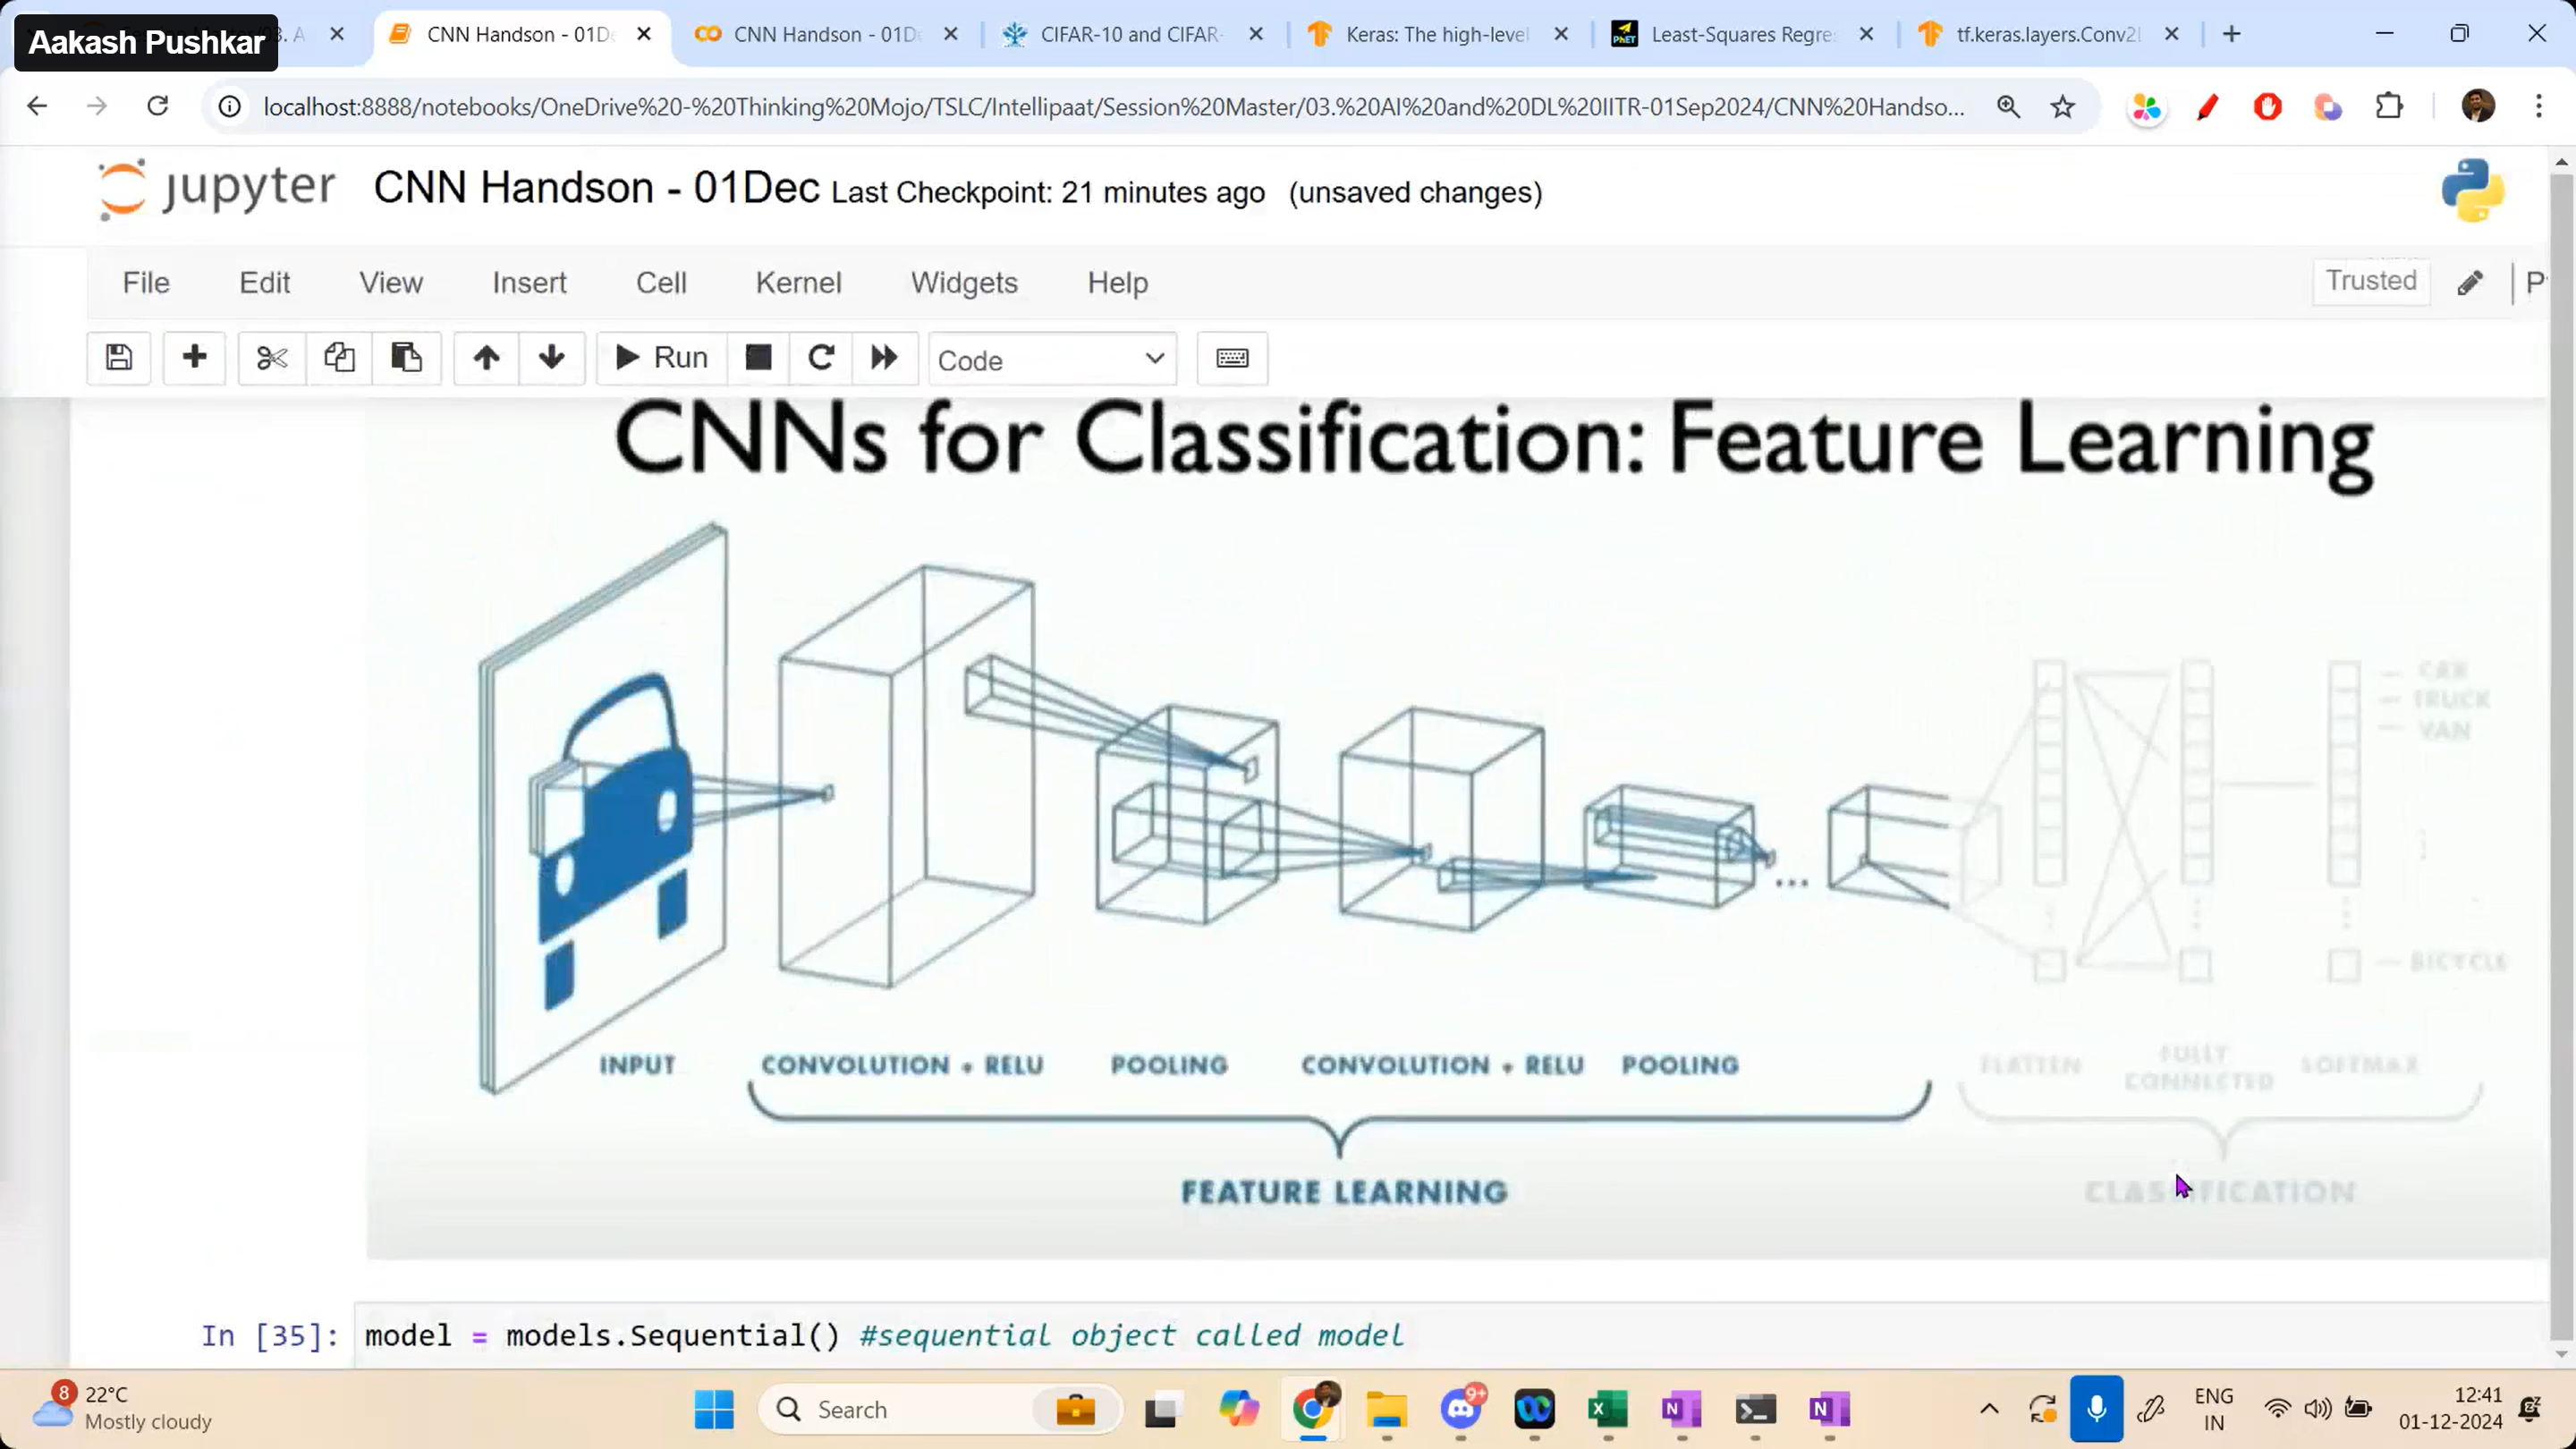

lets add dense layer on top(hidden layer).Fully connected

conv->maxpooling->flatten->dense

In [29]:
model.add(layers.Flatten()) #flattening the output neurons(pixels) of last conv layer=16*64=1024 neurons
model.add(layers.Dense(64,activation='relu')) #hidden layer.we are taking 64 neurons for the hidden layer
model.add(layers.Dense(10,activation='softmax')) #10 neurons for classifcation.10 different classes
#weights calculation=64*1024=65536 weights,64 bias fir each neron in hidden layer. total=65600

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

#compile and train model

In [31]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.3900 - loss: 1.7161 - val_accuracy: 0.4559 - val_loss: 1.5249
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5307 - loss: 1.3125 - val_accuracy: 0.5410 - val_loss: 1.2928
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5905 - loss: 1.1589 - val_accuracy: 0.6056 - val_loss: 1.1358
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6303 - loss: 1.0618 - val_accuracy: 0.6245 - val_loss: 1.0827
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6592 - loss: 0.9776 - val_accuracy: 0.5847 - val_loss: 1.2218
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6817 - loss: 0.9180 - val_accuracy: 0.6350 - val_loss: 1.0854
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7046 - loss: 0.8612 - val_accuracy: 0.6534 - val_loss: 1.0408
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7172 -

In [32]:
#the model is overfitting

Since the model is overfitting we can perfrom normalization 

In [33]:
model=models.Sequential() #so that,all the layers of the model are in sequence
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #first 2d convolution layer with 32 filters
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #another 2d convolution layer with 664 filters
model.add(layers.BatchNormalization()) #after conv2d layer to overcome overfitting
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #another 2d convolution layer with 664 filters
model.add(layers.BatchNormalization()) #after conv2d layer to overcome overfitting
#can either end with conv layer or maxpooling layer

In [34]:
#can add the batch normmalization layer either after conv2d/dense layers
model.add(layers.Flatten()) #flattening the output neurons(pixels) of last conv layer=16*64=1024 neurons
model.add(layers.Dense(64,activation='relu')) #hidden layer.we are taking 64 neurons for the hidden layer
model.add(layers.Dense(10,activation='softmax')) #10 neurons for classifcation.10 different classes
#weights calculation=64*1024=65536 weights,64 bias fir each neron in hidden layer. total=65600

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 123,082 (480.79 KB)

 Trainable params: 122,826 (479.79 KB)

 Non-trainable params: 256 (1.00 KB)

In [36]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.5031 - loss: 1.4001 - val_accuracy: 0.5682 - val_loss: 1.2249
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6487 - loss: 0.9973 - val_accuracy: 0.6000 - val_loss: 1.1353
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7044 - loss: 0.8397 - val_accuracy: 0.6217 - val_loss: 1.0936
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7363 - loss: 0.7492 - val_accuracy: 0.6656 - val_loss: 0.9793
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7669 - loss: 0.6654 - val_accuracy: 0.6712 - val_loss: 0.9754
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7878 - loss: 0.5982 - val_accuracy: 0.6640 - val_loss: 1.0948
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8093 - loss: 0.5401 - val_accuracy: 0.6635 - val_loss: 1.1000
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8271 -

Small improvisation in training accuracy but still the model overfits

Since even after adding batch normalization ,the model hasnt performed well and shows an improvement in training acc but no improvement in testing accuracy.

We now perform Regularisation and dropout

In [50]:
from tensorflow.keras import regularizers

In [51]:
model=models.Sequential() #so that,all the layers of the model are in sequence
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #first 2d convolution layer with 32 filters
###batch normalisation
model.add(layers.BatchNormalization()) #after conv2d layer to overcome overfitting
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions

###dropout layer
model.add(layers.Dropout(0.25)) #25% values dropout-in the small feature map generated by maxpool layer,25%of the values are forced to 0
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01))) #another 2d convolution layer with 64 filters
#added L2 kernel regularizer

###batch normalisation
model.add(layers.BatchNormalization()) #after conv2d layer to overcome overfitting
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions


### dropout layer
model.add(layers.Dropout(0.25)) #25% values dropout-in the small feature map generated by maxpool layer,25%of the values are forced to 0
model.add(layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu')) #another 2d convolution layer with 64 filters

model.add(layers.BatchNormalization()) #after conv2d layer to overcome overfitting
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions

###dropout layer
model.add(layers.Dropout(0.25)) #25% values dropout-in the small feature map generated by maxpool layer,25%of the values are forced to 0
#can either end with conv layer or maxpooling layer

In [48]:
#can add the batch normmalization layer either after conv2d/dense layers
model.add(layers.Flatten()) #flattening the output neurons(pixels) of last conv layer=16*64=1024 neurons
model.add(layers.Dense(64,activation='relu')) #hidden layer.we are taking 64 neurons for the hidden layer
model.add(layers.Dense(10,activation='softmax')) #10 neurons for classifcation.10 different classes
#weights calculation=64*1024=65536 weights,64 bias fir each neron in hidden layer. total=65600

In [49]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.4381 - loss: 1.7758 - val_accuracy: 0.5178 - val_loss: 1.4587
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.5683 - loss: 1.3019 - val_accuracy: 0.5177 - val_loss: 1.4547
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.6150 - loss: 1.1820 - val_accuracy: 0.5811 - val_loss: 1.3301
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.6445 - loss: 1.1082 - val_accuracy: 0.6279 - val_loss: 1.1561
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.6626 - loss: 1.0508 - val_accuracy: 0.6112 - val_loss: 1.2303
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.6770 - loss: 1.0164 - val_accuracy: 0.6777 - val_loss: 1.0258
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6909 - loss: 0.9793 - val_accuracy: 0.6561 - val_loss: 1.1154
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.6985 -

After performing dropouts,batch normalization and adding kernel regulariser(l2) Overfitting is overcomed with a training accuracy-71.39% and testing accuracy-72.26%